# RiskProof AI - Full Model Benchmark on `fraud_oracle.csv`

This notebook is the final tabular ML benchmark for the RiskProof AI demo.

**Project context:** RiskProof AI is a pre-claim evidence intelligence system for insurance brokers and MSME policyholders. The full product vision is multimodal: documents, photos, audio, video, policy clauses, and claim metadata. This public `fraud_oracle.csv` dataset does **not** prove the whole multimodal system by itself. It proves one important module: **claim fraud / risk scoring from structured claim metadata**.

**Main binary target:** `FraudFound_P`

- `0` = low-risk / genuine claim
- `1` = high-risk / suspicious claim

The dataset is highly imbalanced, so the notebook reports accuracy plus precision, recall, F1, balanced accuracy, and confusion matrices. Accuracy is still included because it is required for the project comparison, but fraud recall/F1 should be considered when explaining the model professionally.

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pickle

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
DATA_PATH = Path("fraud_oracle.csv")
OUTPUT_DIR = Path("benchmark_outputs")
MODEL_DIR = Path("saved_models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} was not found. Keep fraud_oracle.csv in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

Dataset shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

None

## 3. Dataset Quality Check and Cleaning

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values per column:")
display(df.isna().sum())

duplicate_count = int(df.duplicated().sum())
missing_count = int(df.isna().sum().sum())
print("\nDuplicate rows before cleaning:", duplicate_count)
print("Total missing values before cleaning:", missing_count)

df = df.drop_duplicates().dropna().reset_index(drop=True)

print("\nDuplicate rows after cleaning:", int(df.duplicated().sum()))
print("Total missing values after cleaning:", int(df.isna().sum().sum()))
print("Cleaned shape:", df.shape)

Columns:
['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']

Missing values per column:


Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64


Duplicate rows before cleaning: 0
Total missing values before cleaning: 0

Duplicate rows after cleaning: 0
Total missing values after cleaning: 0
Cleaned shape: (15420, 33)


## 4. Understand Target and Class Imbalance

,label,count,percentage
FraudFound_P,,,
0,Low-risk / genuine claim,14497,94.01
1,High-risk / suspicious claim,923,5.99


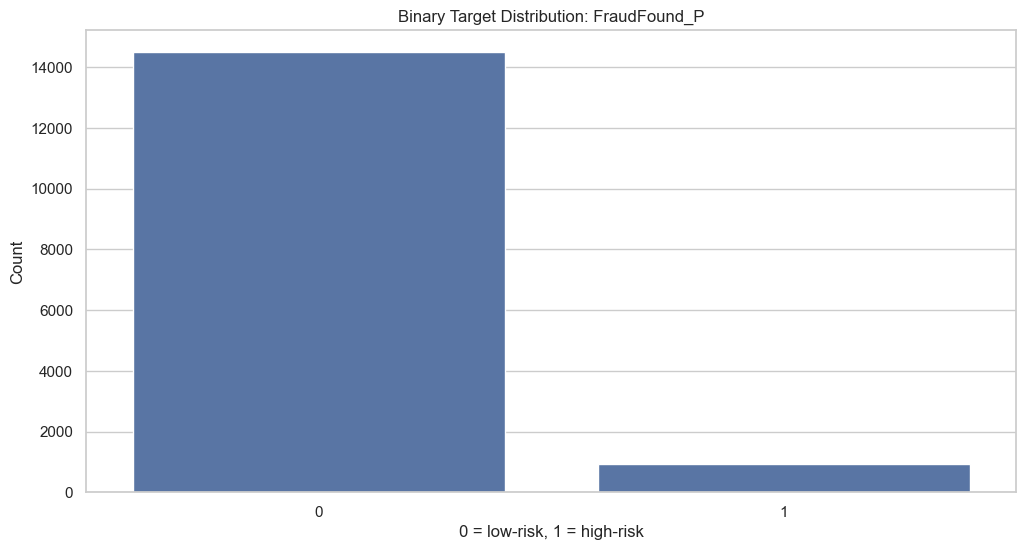

In [4]:
target_col = "FraudFound_P"
id_like_cols = ["PolicyNumber", "RepNumber"]

target_counts = df[target_col].value_counts().sort_index()
target_percent = (df[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "label": ["Low-risk / genuine claim", "High-risk / suspicious claim"],
    "count": target_counts.values,
    "percentage": target_percent.values,
}, index=target_counts.index)

display(target_summary)

ax = sns.countplot(data=df, x=target_col)
ax.set_title("Binary Target Distribution: FraudFound_P")
ax.set_xlabel("0 = low-risk, 1 = high-risk")
ax.set_ylabel("Count")
plt.show()

## 5. Select Inputs and Outputs

In [5]:
# Binary classification output for the RiskProof AI claim-risk module.
y_binary = df[target_col].astype(int)

# Multiclass output for a separate demonstration: predicting policy family.
# This is not the main fraud target; it proves multiclass classification.
multiclass_target_name = "BasePolicy"
y_multiclass_raw = df[multiclass_target_name]
multiclass_encoder = LabelEncoder()
y_multiclass = multiclass_encoder.fit_transform(y_multiclass_raw)

# Remove target columns and ID-like columns from model inputs.
# PolicyNumber is unique and can cause misleading memorization.
drop_cols = [target_col, multiclass_target_name] + id_like_cols
feature_source = df.drop(columns=drop_cols)

numeric_features = feature_source.select_dtypes(include=["number"]).columns.tolist()
categorical_features = feature_source.select_dtypes(exclude=["number"]).columns.tolist()

print("Main binary output / target:", target_col)
print("Multiclass demo output / target:", multiclass_target_name)
print("\nNumeric input columns:", numeric_features)
print("\nCategorical input columns:", categorical_features)

X_encoded = pd.get_dummies(feature_source, drop_first=True, dtype=int)

print("\nEncoded feature matrix shape:", X_encoded.shape)
display(X_encoded.head())

input_output_notes = pd.DataFrame({
    "Role": ["Input features", "Main output", "Multiclass demo output", "Excluded"],
    "Columns": [
        ", ".join(feature_source.columns),
        target_col,
        multiclass_target_name,
        ", ".join(drop_cols),
    ],
    "Reason": [
        "Claim, customer, policy, vehicle, timing, and evidence metadata used for risk scoring.",
        "Binary fraud/risk label used for the main RiskProof AI demo model.",
        "Separate multiclass classification demonstration.",
        "Targets and ID-like columns should not be used as model inputs.",
    ],
})
display(input_output_notes)

Main binary output / target: FraudFound_P
Multiclass demo output / target: BasePolicy

Numeric input columns: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'Deductible', 'DriverRating', 'Year']

Categorical input columns: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars']

Encoded feature matrix shape: (15420, 120)


,WeekOfMonth,WeekOfMonthClaimed,Age,Deductible,DriverRating,Year,Month_Aug,Month_Dec,Month_Feb,Month_Jan,...,NumberOfSuppliments_more than 5,NumberOfSuppliments_none,AddressChange_Claim_2 to 3 years,AddressChange_Claim_4 to 8 years,AddressChange_Claim_no change,AddressChange_Claim_under 6 months,NumberOfCars_2 vehicles,NumberOfCars_3 to 4,NumberOfCars_5 to 8,NumberOfCars_more than 8
0,5,1,21,300,1,1994,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
1,3,4,34,400,4,1994,0,0,0,1,...,0,1,0,0,1,0,0,0,0,0
2,5,2,47,400,3,1994,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
3,2,1,65,400,2,1994,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
4,5,2,27,400,1,1994,0,0,0,1,...,0,1,0,0,1,0,0,0,0,0


,Role,Columns,Reason
0,Input features,"Month, WeekOfMonth, DayOfWeek, Make, AccidentA...","Claim, customer, policy, vehicle, timing, and ..."
1,Main output,FraudFound_P,Binary fraud/risk label used for the main Risk...
2,Multiclass demo output,BasePolicy,Separate multiclass classification demonstration.
3,Excluded,"FraudFound_P, BasePolicy, PolicyNumber, RepNumber",Targets and ID-like columns should not be used...


## 6. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_binary,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_binary,
)

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_encoded,
    y_multiclass,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_multiclass,
)

print("Binary train shape:", X_train.shape)
print("Binary test shape:", X_test.shape)
print("Binary train target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("Binary test target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Binary train shape: (12336, 120)
Binary test shape: (3084, 120)
Binary train target distribution:
FraudFound_P
0    0.9402
1    0.0598
Name: proportion, dtype: float64
Binary test target distribution:
FraudFound_P
0    0.94
1    0.06
Name: proportion, dtype: float64


## 7. Helper Functions for Metrics, Predictions, and Saving

In [7]:
binary_results = []
trained_models = {}
prediction_frames = []

risk_label_map = {
    0: "Low-risk / genuine claim",
    1: "High-risk / suspicious claim",
}

def evaluate_binary_model(model_name, y_true, y_pred, model_object, params=None, y_score=None):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_fraud": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_fraud": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_fraud": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "parameters": params or {},
    }
    binary_results.append(metrics)
    trained_models[model_name] = {
        "model": model_object,
        "parameters": params or {},
        "feature_columns": X_encoded.columns.tolist(),
    }

    pred_df = pd.DataFrame({
        "model": model_name,
        "actual": y_true.to_numpy() if hasattr(y_true, "to_numpy") else np.asarray(y_true),
        "predicted": y_pred,
        "actual_label": [risk_label_map[int(v)] for v in y_true],
        "predicted_label": [risk_label_map[int(v)] for v in y_pred],
    })
    if y_score is not None:
        pred_df["risk_score"] = y_score
    prediction_frames.append(pred_df)

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Parameters:", params or {})
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Balanced accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Fraud precision: {metrics['precision_fraud']:.4f}")
    print(f"Fraud recall: {metrics['recall_fraud']:.4f}")
    print(f"Fraud F1-score: {metrics['f1_fraud']:.4f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=list(risk_label_map.values()), zero_division=0))
    print("Sample predictions:", y_pred[:10])

    return metrics

def save_model_bundle(model_name, bundle):
    safe_name = model_name.lower().replace(" ", "_").replace("/", "_")
    pkl_path = MODEL_DIR / f"{safe_name}.pkl"
    joblib_path = MODEL_DIR / f"{safe_name}.joblib"
    with open(pkl_path, "wb") as f:
        pickle.dump(bundle, f)
    joblib.dump(bundle, joblib_path)
    return pkl_path, joblib_path

def predict_with_threshold(values, threshold=0.5):
    values = np.clip(values, 0, 1)
    return (values >= threshold).astype(int)

## 8. Simple Linear Regression Baseline

In [8]:
simple_X = df[["Age"]]
X_train_sr, X_test_sr, y_train_sr, y_test_sr = train_test_split(
    simple_X,
    y_binary,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_binary,
)

simple_lr_model = LinearRegression()
simple_lr_model.fit(X_train_sr, y_train_sr)
simple_raw_pred = simple_lr_model.predict(X_test_sr)
simple_class_pred = predict_with_threshold(simple_raw_pred)

print("Regression metrics against binary target:")
print("MAE:", mean_absolute_error(y_test_sr, simple_raw_pred))
print("RMSE:", root_mean_squared_error(y_test_sr, simple_raw_pred))
print("R2:", r2_score(y_test_sr, simple_raw_pred))

evaluate_binary_model(
    "Simple Linear Regression",
    y_test_sr,
    simple_class_pred,
    simple_lr_model,
    params={"features": ["Age"], "threshold": 0.5},
    y_score=np.clip(simple_raw_pred, 0, 1),
)

Regression metrics against binary target:
MAE: 0.11252153197412733
RMSE: 0.2372729941904684
R2: 0.00159805942203739

Simple Linear Regression
------------------------
Parameters: {'features': ['Age'], 'threshold': 0.5}
Accuracy: 0.9400
Balanced accuracy: 0.5000
Fraud precision: 0.0000
Fraud recall: 0.0000
Fraud F1-score: 0.0000

Confusion matrix:
[[2899    0]
 [ 185    0]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.94      1.00      0.97      2899
High-risk / suspicious claim       0.00      0.00      0.00       185

                    accuracy                           0.94      3084
                   macro avg       0.47      0.50      0.48      3084
                weighted avg       0.88      0.94      0.91      3084

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


{'model': 'Simple Linear Regression',
 'accuracy': 0.9400129701686122,
 'balanced_accuracy': np.float64(0.5),
 'precision_fraud': 0.0,
 'recall_fraud': 0.0,
 'f1_fraud': 0.0,
 'parameters': {'features': ['Age'], 'threshold': 0.5}}

## 9. Multiple Linear Regression Baseline

In [9]:
multi_lr_model = LinearRegression()
multi_lr_model.fit(X_train, y_train)
multi_raw_pred = multi_lr_model.predict(X_test)
multi_class_pred = predict_with_threshold(multi_raw_pred)

print("Regression metrics against binary target:")
print("MAE:", mean_absolute_error(y_test, multi_raw_pred))
print("RMSE:", root_mean_squared_error(y_test, multi_raw_pred))
print("R2:", r2_score(y_test, multi_raw_pred))

evaluate_binary_model(
    "Multiple Linear Regression",
    y_test,
    multi_class_pred,
    multi_lr_model,
    params={"features": "all one-hot encoded features", "threshold": 0.5},
    y_score=np.clip(multi_raw_pred, 0, 1),
)

Regression metrics against binary target:
MAE: 0.11603664921836039
RMSE: 0.22956572998305944
R2: 0.0654061744922354

Multiple Linear Regression
--------------------------
Parameters: {'features': 'all one-hot encoded features', 'threshold': 0.5}
Accuracy: 0.9400
Balanced accuracy: 0.5000
Fraud precision: 0.0000
Fraud recall: 0.0000
Fraud F1-score: 0.0000

Confusion matrix:
[[2899    0]
 [ 185    0]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.94      1.00      0.97      2899
High-risk / suspicious claim       0.00      0.00      0.00       185

                    accuracy                           0.94      3084
                   macro avg       0.47      0.50      0.48      3084
                weighted avg       0.88      0.94      0.91      3084

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


{'model': 'Multiple Linear Regression',
 'accuracy': 0.9400129701686122,
 'balanced_accuracy': np.float64(0.5),
 'precision_fraud': 0.0,
 'recall_fraud': 0.0,
 'f1_fraud': 0.0,
 'parameters': {'features': 'all one-hot encoded features', 'threshold': 0.5}}

## 10. Logistic Regression - Binary Classification

In [10]:
best_lr_model = None
best_lr_params = None
best_lr_accuracy = -1
best_lr_pred = None
best_lr_score = None

for c_value in [0.01, 0.1, 1.0, 5.0, 10.0]:
    for class_weight in [None, "balanced"]:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=5000,
                solver="lbfgs",
                C=c_value,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
            )),
        ])
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        print(f"C={c_value}, class_weight={class_weight}, accuracy={acc:.4f}")
        if acc > best_lr_accuracy:
            best_lr_accuracy = acc
            best_lr_model = model
            best_lr_params = {"C": c_value, "class_weight": class_weight}
            best_lr_pred = pred
            best_lr_score = model.predict_proba(X_test)[:, 1]

evaluate_binary_model(
    "Logistic Regression",
    y_test,
    best_lr_pred,
    best_lr_model,
    params=best_lr_params,
    y_score=best_lr_score,
)

C=0.01, class_weight=None, accuracy=0.9400
C=0.01, class_weight=balanced, accuracy=0.6401


C=0.1, class_weight=None, accuracy=0.9400
C=0.1, class_weight=balanced, accuracy=0.6436


C=1.0, class_weight=None, accuracy=0.9407


C=1.0, class_weight=balanced, accuracy=0.6436
C=5.0, class_weight=None, accuracy=0.9407


C=5.0, class_weight=balanced, accuracy=0.6446
C=10.0, class_weight=None, accuracy=0.9407


C=10.0, class_weight=balanced, accuracy=0.6443

Logistic Regression
-------------------
Parameters: {'C': 1.0, 'class_weight': None}
Accuracy: 0.9407
Balanced accuracy: 0.5079
Fraud precision: 0.7500
Fraud recall: 0.0162
Fraud F1-score: 0.0317

Confusion matrix:
[[2898    1]
 [ 182    3]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.94      1.00      0.97      2899
High-risk / suspicious claim       0.75      0.02      0.03       185

                    accuracy                           0.94      3084
                   macro avg       0.85      0.51      0.50      3084
                weighted avg       0.93      0.94      0.91      3084

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


{'model': 'Logistic Regression',
 'accuracy': 0.9406614785992218,
 'balanced_accuracy': np.float64(0.5079356348414644),
 'precision_fraud': 0.75,
 'recall_fraud': 0.016216216216216217,
 'f1_fraud': 0.031746031746031744,
 'parameters': {'C': 1.0, 'class_weight': None}}

## 11. Decision Tree Classification

In [11]:
best_dt_model = None
best_dt_params = None
best_dt_accuracy = -1
best_dt_pred = None
best_dt_score = None

for criterion in ["gini", "entropy"]:
    for max_depth in [3, 5, 7, 10, None]:
        for min_samples_leaf in [1, 5, 20]:
            model = DecisionTreeClassifier(
                criterion=criterion,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=RANDOM_STATE,
            )
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            acc = accuracy_score(y_test, pred)
            print(
                f"criterion={criterion}, max_depth={max_depth}, "
                f"min_samples_leaf={min_samples_leaf}, accuracy={acc:.4f}"
            )
            if acc > best_dt_accuracy:
                best_dt_accuracy = acc
                best_dt_model = model
                best_dt_params = {
                    "criterion": criterion,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                }
                best_dt_pred = pred
                best_dt_score = model.predict_proba(X_test)[:, 1]

evaluate_binary_model(
    "Decision Tree",
    y_test,
    best_dt_pred,
    best_dt_model,
    params=best_dt_params,
    y_score=best_dt_score,
)

criterion=gini, max_depth=3, min_samples_leaf=1, accuracy=0.9403
criterion=gini, max_depth=3, min_samples_leaf=5, accuracy=0.9403


criterion=gini, max_depth=3, min_samples_leaf=20, accuracy=0.9403
criterion=gini, max_depth=5, min_samples_leaf=1, accuracy=0.9410


criterion=gini, max_depth=5, min_samples_leaf=5, accuracy=0.9416


criterion=gini, max_depth=5, min_samples_leaf=20, accuracy=0.9416
criterion=gini, max_depth=7, min_samples_leaf=1, accuracy=0.9407


criterion=gini, max_depth=7, min_samples_leaf=5, accuracy=0.9410


...

criterion=entropy, max_depth=7, min_samples_leaf=1, accuracy=0.9410
criterion=entropy, max_depth=7, min_samples_leaf=5, accuracy=0.9416
criterion=entropy, max_depth=7, min_samples_leaf=20, accuracy=0.9403


criterion=entropy, max_depth=10, min_samples_leaf=1, accuracy=0.9361
criterion=entropy, max_depth=10, min_samples_leaf=5, accuracy=0.9381
criterion=entropy, max_depth=10, min_samples_leaf=20, accuracy=0.9384


criterion=entropy, max_depth=None, min_samples_leaf=1, accuracy=0.9011
criterion=entropy, max_depth=None, min_samples_leaf=5, accuracy=0.9102


criterion=entropy, max_depth=None, min_samples_leaf=20, accuracy=0.9384

Decision Tree
-------------
Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5}
Accuracy: 0.9416
Balanced accuracy: 0.5135
Fraud precision: 1.0000
Fraud recall: 0.0270
Fraud F1-score: 0.0526

Confusion matrix:
[[2899    0]
 [ 180    5]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.94      1.00      0.97      2899
High-risk / suspicious claim       1.00      0.03      0.05       185

                    accuracy                           0.94      3084
                   macro avg       0.97      0.51      0.51      3084
                weighted avg       0.95      0.94      0.91      3084

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


{'model': 'Decision Tree',
 'accuracy': 0.9416342412451362,
 'balanced_accuracy': np.float64(0.5135135135135135),
 'precision_fraud': 1.0,
 'recall_fraud': 0.02702702702702703,
 'f1_fraud': 0.05263157894736842,
 'parameters': {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5}}

## 12. Random Forest Classification

In [12]:
best_rf_model = None
best_rf_params = None
best_rf_accuracy = -1
best_rf_pred = None
best_rf_score = None

for n_estimators in [100, 200]:
    for max_depth in [None, 10, 20]:
        for class_weight in [None, "balanced"]:
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            acc = accuracy_score(y_test, pred)
            print(
                f"n_estimators={n_estimators}, max_depth={max_depth}, "
                f"class_weight={class_weight}, accuracy={acc:.4f}"
            )
            if acc > best_rf_accuracy:
                best_rf_accuracy = acc
                best_rf_model = model
                best_rf_params = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "class_weight": class_weight,
                }
                best_rf_pred = pred
                best_rf_score = model.predict_proba(X_test)[:, 1]

evaluate_binary_model(
    "Random Forest",
    y_test,
    best_rf_pred,
    best_rf_model,
    params=best_rf_params,
    y_score=best_rf_score,
)

n_estimators=100, max_depth=None, class_weight=None, accuracy=0.9400


n_estimators=100, max_depth=None, class_weight=balanced, accuracy=0.9403


n_estimators=100, max_depth=10, class_weight=None, accuracy=0.9400


n_estimators=100, max_depth=10, class_weight=balanced, accuracy=0.7163


n_estimators=100, max_depth=20, class_weight=None, accuracy=0.9403


...

n_estimators=200, max_depth=10, class_weight=None, accuracy=0.9400


n_estimators=200, max_depth=10, class_weight=balanced, accuracy=0.7134


n_estimators=200, max_depth=20, class_weight=None, accuracy=0.9403


n_estimators=200, max_depth=20, class_weight=balanced, accuracy=0.9319

Random Forest
-------------
Parameters: {'n_estimators': 100, 'max_depth': None, 'class_weight': 'balanced'}
Accuracy: 0.9403
Balanced accuracy: 0.5027
Fraud precision: 1.0000
Fraud recall: 0.0054
Fraud F1-score: 0.0108

Confusion matrix:
[[2899    0]
 [ 184    1]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.94      1.00      0.97      2899
High-risk / suspicious claim       1.00      0.01      0.01       185

                    accuracy                           0.94      3084
                   macro avg       0.97      0.50      0.49      3084
                weighted avg       0.94      0.94      0.91      3084

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


{'model': 'Random Forest',
 'accuracy': 0.940337224383917,
 'balanced_accuracy': np.float64(0.5027027027027027),
 'precision_fraud': 1.0,
 'recall_fraud': 0.005405405405405406,
 'f1_fraud': 0.010752688172043012,
 'parameters': {'n_estimators': 100,
  'max_depth': None,
  'class_weight': 'balanced'}}

## 13. Naive Bayes Classification

In [13]:
best_nb_model = None
best_nb_params = None
best_nb_accuracy = -1
best_nb_pred = None
best_nb_score = None

for var_smoothing in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", GaussianNB(var_smoothing=var_smoothing)),
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"var_smoothing={var_smoothing}, accuracy={acc:.4f}")
    if acc > best_nb_accuracy:
        best_nb_accuracy = acc
        best_nb_model = model
        best_nb_params = {"var_smoothing": var_smoothing}
        best_nb_pred = pred
        best_nb_score = model.predict_proba(X_test)[:, 1]

evaluate_binary_model(
    "Naive Bayes",
    y_test,
    best_nb_pred,
    best_nb_model,
    params=best_nb_params,
    y_score=best_nb_score,
)

var_smoothing=1e-09, accuracy=0.0872


var_smoothing=1e-08, accuracy=0.0895


var_smoothing=1e-07, accuracy=0.0940
var_smoothing=1e-06, accuracy=0.1008


var_smoothing=1e-05, accuracy=0.1025
var_smoothing=0.0001, accuracy=0.1038



Naive Bayes
-----------
Parameters: {'var_smoothing': 0.0001}
Accuracy: 0.1038
Balanced accuracy: 0.5030
Fraud precision: 0.0603
Fraud recall: 0.9568
Fraud F1-score: 0.1135

Confusion matrix:
[[ 143 2756]
 [   8  177]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.95      0.05      0.09      2899
High-risk / suspicious claim       0.06      0.96      0.11       185

                    accuracy                           0.10      3084
                   macro avg       0.50      0.50      0.10      3084
                weighted avg       0.89      0.10      0.09      3084

Sample predictions: [1 1 1 1 0 1 1 1 1 1]


{'model': 'Naive Bayes',
 'accuracy': 0.10376134889753567,
 'balanced_accuracy': np.float64(0.5030420555084232),
 'precision_fraud': 0.06034776679168087,
 'recall_fraud': 0.9567567567567568,
 'f1_fraud': 0.11353431686978832,
 'parameters': {'var_smoothing': 0.0001}}

## 14. KNN Classification

In [14]:
best_knn_model = None
best_knn_params = None
best_knn_accuracy = -1
best_knn_pred = None
best_knn_score = None

for n_neighbors in [3, 5, 7, 9, 11]:
    for weights in ["uniform", "distance"]:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
            )),
        ])
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        print(f"n_neighbors={n_neighbors}, weights={weights}, accuracy={acc:.4f}")
        if acc > best_knn_accuracy:
            best_knn_accuracy = acc
            best_knn_model = model
            best_knn_params = {
                "n_neighbors": n_neighbors,
                "weights": weights,
            }
            best_knn_pred = pred
            best_knn_score = model.predict_proba(X_test)[:, 1]

evaluate_binary_model(
    "KNN",
    y_test,
    best_knn_pred,
    best_knn_model,
    params=best_knn_params,
    y_score=best_knn_score,
)

n_neighbors=3, weights=uniform, accuracy=0.9274


n_neighbors=3, weights=distance, accuracy=0.9274


n_neighbors=5, weights=uniform, accuracy=0.9377


n_neighbors=5, weights=distance, accuracy=0.9377


n_neighbors=7, weights=uniform, accuracy=0.9374


...

n_neighbors=9, weights=uniform, accuracy=0.9400


n_neighbors=9, weights=distance, accuracy=0.9400


n_neighbors=11, weights=uniform, accuracy=0.9400


n_neighbors=11, weights=distance, accuracy=0.9400

KNN
---
Parameters: {'n_neighbors': 9, 'weights': 'uniform'}
Accuracy: 0.9400
Balanced accuracy: 0.5025
Fraud precision: 0.5000
Fraud recall: 0.0054
Fraud F1-score: 0.0107

Confusion matrix:
[[2898    1]
 [ 184    1]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.94      1.00      0.97      2899
High-risk / suspicious claim       0.50      0.01      0.01       185

                    accuracy                           0.94      3084
                   macro avg       0.72      0.50      0.49      3084
                weighted avg       0.91      0.94      0.91      3084

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


{'model': 'KNN',
 'accuracy': 0.9400129701686122,
 'balanced_accuracy': np.float64(0.5025302294360591),
 'precision_fraud': 0.5,
 'recall_fraud': 0.005405405405405406,
 'f1_fraud': 0.0106951871657754,
 'parameters': {'n_neighbors': 9, 'weights': 'uniform'}}

## 15. SVM Classification

In [15]:
best_svm_model = None
best_svm_params = None
best_svm_accuracy = -1
best_svm_pred = None
best_svm_score = None

# LinearSVC is used instead of kernel SVC because kernel SVC is too slow
# for this full one-hot encoded dataset during a final demo run.
for c_value in [0.01, 0.1, 1.0, 5.0]:
    for class_weight in [None, "balanced"]:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LinearSVC(
                C=c_value,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                max_iter=10000,
            )),
        ])
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        print(f"LinearSVC C={c_value}, class_weight={class_weight}, accuracy={acc:.4f}")
        if acc > best_svm_accuracy:
            best_svm_accuracy = acc
            best_svm_model = model
            best_svm_params = {
                "algorithm": "LinearSVC",
                "C": c_value,
                "class_weight": class_weight,
            }
            best_svm_pred = pred
            best_svm_score = model.decision_function(X_test)

evaluate_binary_model(
    "SVM",
    y_test,
    best_svm_pred,
    best_svm_model,
    params=best_svm_params,
    y_score=best_svm_score,
)

LinearSVC C=0.01, class_weight=None, accuracy=0.9400


LinearSVC C=0.01, class_weight=balanced, accuracy=0.6268


LinearSVC C=0.1, class_weight=None, accuracy=0.9400


LinearSVC C=0.1, class_weight=balanced, accuracy=0.6278


LinearSVC C=1.0, class_weight=None, accuracy=0.9400


LinearSVC C=1.0, class_weight=balanced, accuracy=0.6281


LinearSVC C=5.0, class_weight=None, accuracy=0.9400


LinearSVC C=5.0, class_weight=balanced, accuracy=0.6284

SVM
---
Parameters: {'algorithm': 'LinearSVC', 'C': 0.01, 'class_weight': None}
Accuracy: 0.9400
Balanced accuracy: 0.5000
Fraud precision: 0.0000
Fraud recall: 0.0000
Fraud F1-score: 0.0000

Confusion matrix:
[[2899    0]
 [ 185    0]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.94      1.00      0.97      2899
High-risk / suspicious claim       0.00      0.00      0.00       185

                    accuracy                           0.94      3084
                   macro avg       0.47      0.50      0.48      3084
                weighted avg       0.88      0.94      0.91      3084

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


{'model': 'SVM',
 'accuracy': 0.9400129701686122,
 'balanced_accuracy': np.float64(0.5),
 'precision_fraud': 0.0,
 'recall_fraud': 0.0,
 'f1_fraud': 0.0,
 'parameters': {'algorithm': 'LinearSVC', 'C': 0.01, 'class_weight': None}}

## 16. KMeans Clustering as an Unsupervised Baseline

In [16]:
def map_clusters_to_labels(cluster_ids, true_labels):
    mapping = {}
    true_labels = np.asarray(true_labels)
    for cluster_id in np.unique(cluster_ids):
        mask = cluster_ids == cluster_id
        majority_label = pd.Series(true_labels[mask]).mode()[0]
        mapping[int(cluster_id)] = int(majority_label)
    return mapping

def apply_cluster_mapping(cluster_ids, mapping):
    default_label = 0
    return np.array([mapping.get(int(cluster_id), default_label) for cluster_id in cluster_ids])

best_kmeans_model = None
best_kmeans_params = None
best_kmeans_accuracy = -1
best_kmeans_pred = None
best_cluster_mapping = None

scaler_kmeans = StandardScaler()
X_train_kmeans = scaler_kmeans.fit_transform(X_train)
X_test_kmeans = scaler_kmeans.transform(X_test)

for n_clusters in [2, 3, 4, 5]:
    model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    train_clusters = model.fit_predict(X_train_kmeans)
    cluster_mapping = map_clusters_to_labels(train_clusters, y_train)
    test_clusters = model.predict(X_test_kmeans)
    pred = apply_cluster_mapping(test_clusters, cluster_mapping)
    acc = accuracy_score(y_test, pred)
    print(f"n_clusters={n_clusters}, mapped-label accuracy={acc:.4f}, mapping={cluster_mapping}")
    if acc > best_kmeans_accuracy:
        best_kmeans_accuracy = acc
        best_kmeans_model = model
        best_kmeans_params = {"n_clusters": n_clusters, "cluster_mapping": cluster_mapping}
        best_kmeans_pred = pred
        best_cluster_mapping = cluster_mapping

kmeans_bundle_model = {
    "model": best_kmeans_model,
    "scaler": scaler_kmeans,
    "cluster_mapping": best_cluster_mapping,
}

evaluate_binary_model(
    "KMeans",
    y_test,
    best_kmeans_pred,
    kmeans_bundle_model,
    params=best_kmeans_params,
)

n_clusters=2, mapped-label accuracy=0.9400, mapping={0: 0, 1: 0}


n_clusters=3, mapped-label accuracy=0.9400, mapping={0: 0, 1: 0, 2: 0}


n_clusters=4, mapped-label accuracy=0.9400, mapping={0: 0, 1: 0, 2: 0, 3: 0}


n_clusters=5, mapped-label accuracy=0.9400, mapping={0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

KMeans
------
Parameters: {'n_clusters': 2, 'cluster_mapping': {0: 0, 1: 0}}
Accuracy: 0.9400
Balanced accuracy: 0.5000
Fraud precision: 0.0000
Fraud recall: 0.0000
Fraud F1-score: 0.0000

Confusion matrix:
[[2899    0]
 [ 185    0]]

Classification report:
                              precision    recall  f1-score   support

    Low-risk / genuine claim       0.94      1.00      0.97      2899
High-risk / suspicious claim       0.00      0.00      0.00       185

                    accuracy                           0.94      3084
                   macro avg       0.47      0.50      0.48      3084
                weighted avg       0.88      0.94      0.91      3084

Sample predictions: [0 0 0 0 0 0 0 0 0 0]


{'model': 'KMeans',
 'accuracy': 0.9400129701686122,
 'balanced_accuracy': np.float64(0.5),
 'precision_fraud': 0.0,
 'recall_fraud': 0.0,
 'f1_fraud': 0.0,
 'parameters': {'n_clusters': 2, 'cluster_mapping': {0: 0, 1: 0}}}

## 17. Logistic Regression - Multiclass Classification

In [17]:
best_mc_model = None
best_mc_params = None
best_mc_accuracy = -1
best_mc_pred = None

for c_value in [0.01, 0.1, 1.0, 5.0, 10.0]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            solver="lbfgs",
            C=c_value,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(X_train_mc, y_train_mc)
    pred = model.predict(X_test_mc)
    acc = accuracy_score(y_test_mc, pred)
    print(f"C={c_value}, multiclass accuracy={acc:.4f}")
    if acc > best_mc_accuracy:
        best_mc_accuracy = acc
        best_mc_model = model
        best_mc_params = {"C": c_value}
        best_mc_pred = pred

print("\nBest multiclass parameters:", best_mc_params)
print("Best multiclass accuracy:", best_mc_accuracy)
print("Classes:", multiclass_encoder.classes_.tolist())
print("Sample multiclass predictions:", multiclass_encoder.inverse_transform(best_mc_pred[:10]))
print("\nMulticlass confusion matrix:")
print(confusion_matrix(y_test_mc, best_mc_pred))
print("\nMulticlass classification report:")
print(classification_report(
    y_test_mc,
    best_mc_pred,
    target_names=multiclass_encoder.classes_,
    zero_division=0,
))

trained_models["Logistic Regression Multiclass"] = {
    "model": best_mc_model,
    "parameters": best_mc_params,
    "feature_columns": X_encoded.columns.tolist(),
    "target_encoder": multiclass_encoder,
}

C=0.01, multiclass accuracy=1.0000


C=0.1, multiclass accuracy=1.0000


C=1.0, multiclass accuracy=1.0000


C=5.0, multiclass accuracy=1.0000


C=10.0, multiclass accuracy=1.0000

Best multiclass parameters: {'C': 0.01}
Best multiclass accuracy: 1.0
Classes: ['All Perils', 'Collision', 'Liability']
Sample multiclass predictions: ['All Perils' 'Collision' 'Liability' 'Collision' 'Collision' 'Collision'
 'Liability' 'Collision' 'All Perils' 'All Perils']

Multiclass confusion matrix:
[[ 890    0    0]
 [   0 1192    0]
 [   0    0 1002]]

Multiclass classification report:
              precision    recall  f1-score   support

  All Perils       1.00      1.00      1.00       890
   Collision       1.00      1.00      1.00      1192
   Liability       1.00      1.00      1.00      1002

    accuracy                           1.00      3084
   macro avg       1.00      1.00      1.00      3084
weighted avg       1.00      1.00      1.00      3084



## 18. Compare All Binary Models and Select Final Best Algorithm

In [18]:
comparison_df = pd.DataFrame(binary_results)
comparison_df["accuracy"] = comparison_df["accuracy"].astype(float)
comparison_df["balanced_accuracy"] = comparison_df["balanced_accuracy"].astype(float)
comparison_df["precision_fraud"] = comparison_df["precision_fraud"].astype(float)
comparison_df["recall_fraud"] = comparison_df["recall_fraud"].astype(float)
comparison_df["f1_fraud"] = comparison_df["f1_fraud"].astype(float)

comparison_df = comparison_df.sort_values(
    by=["accuracy", "f1_fraud", "balanced_accuracy"],
    ascending=False,
).reset_index(drop=True)

display(comparison_df)

# For final project model selection, exclude regression baselines.
eligible_final_models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Naive Bayes",
    "KNN",
    "SVM",
    "KMeans",
]
final_comparison_df = comparison_df[comparison_df["model"].isin(eligible_final_models)].copy()
best_accuracy_row = final_comparison_df.sort_values(
    by=["accuracy", "f1_fraud", "balanced_accuracy"],
    ascending=False,
).iloc[0]
best_fraud_f1_row = final_comparison_df.sort_values(
    by=["f1_fraud", "recall_fraud", "balanced_accuracy"],
    ascending=False,
).iloc[0]

best_model_name = best_accuracy_row["model"]
best_model_accuracy = float(best_accuracy_row["accuracy"])

print("Final best algorithm by accuracy:", best_model_name)
print("Final best accuracy:", best_model_accuracy)
print("\nProfessional note:")
print(
    "Because fraud cases are only about 6% of this dataset, accuracy can be misleading. "
    f"The best model by fraud F1 is {best_fraud_f1_row['model']} "
    f"with fraud F1={best_fraud_f1_row['f1_fraud']:.4f}."
)

comparison_df.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)
all_predictions_df = pd.concat(prediction_frames, ignore_index=True)
all_predictions_df.to_csv(OUTPUT_DIR / "per_model_predictions.csv", index=False)

print("\nSaved:")
print(OUTPUT_DIR / "model_comparison_metrics.csv")
print(OUTPUT_DIR / "per_model_predictions.csv")

,model,accuracy,balanced_accuracy,precision_fraud,recall_fraud,f1_fraud,parameters
0,Decision Tree,0.941634,0.513514,1.000000,0.027027,0.052632,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."
1,Logistic Regression,0.940661,0.507936,0.750000,0.016216,0.031746,"{'C': 1.0, 'class_weight': None}"
2,Random Forest,0.940337,0.502703,1.000000,0.005405,0.010753,"{'n_estimators': 100, 'max_depth': None, 'clas..."
3,KNN,0.940013,0.502530,0.500000,0.005405,0.010695,"{'n_neighbors': 9, 'weights': 'uniform'}"
4,Simple Linear Regression,0.940013,0.500000,0.000000,0.000000,0.000000,"{'features': ['Age'], 'threshold': 0.5}"
5,Multiple Linear Regression,0.940013,0.500000,0.000000,0.000000,0.000000,"{'features': 'all one-hot encoded features', '..."
6,SVM,0.940013,0.500000,0.000000,0.000000,0.000000,"{'algorithm': 'LinearSVC', 'C': 0.01, 'class_w..."
7,KMeans,0.940013,0.500000,0.000000,0.000000,0.000000,"{'n_clusters': 2, 'cluster_mapping': {0: 0, 1:..."
8,Naive Bayes,0.103761,0.503042,0.060348,0.956757,0.113534,{'var_smoothing': 0.0001}


Final best algorithm by accuracy: Decision Tree
Final best accuracy: 0.9416342412451362

Professional note:
Because fraud cases are only about 6% of this dataset, accuracy can be misleading. The best model by fraud F1 is Naive Bayes with fraud F1=0.1135.

Saved:
benchmark_outputs\model_comparison_metrics.csv
benchmark_outputs\per_model_predictions.csv


## 19. Visualize Model Comparison

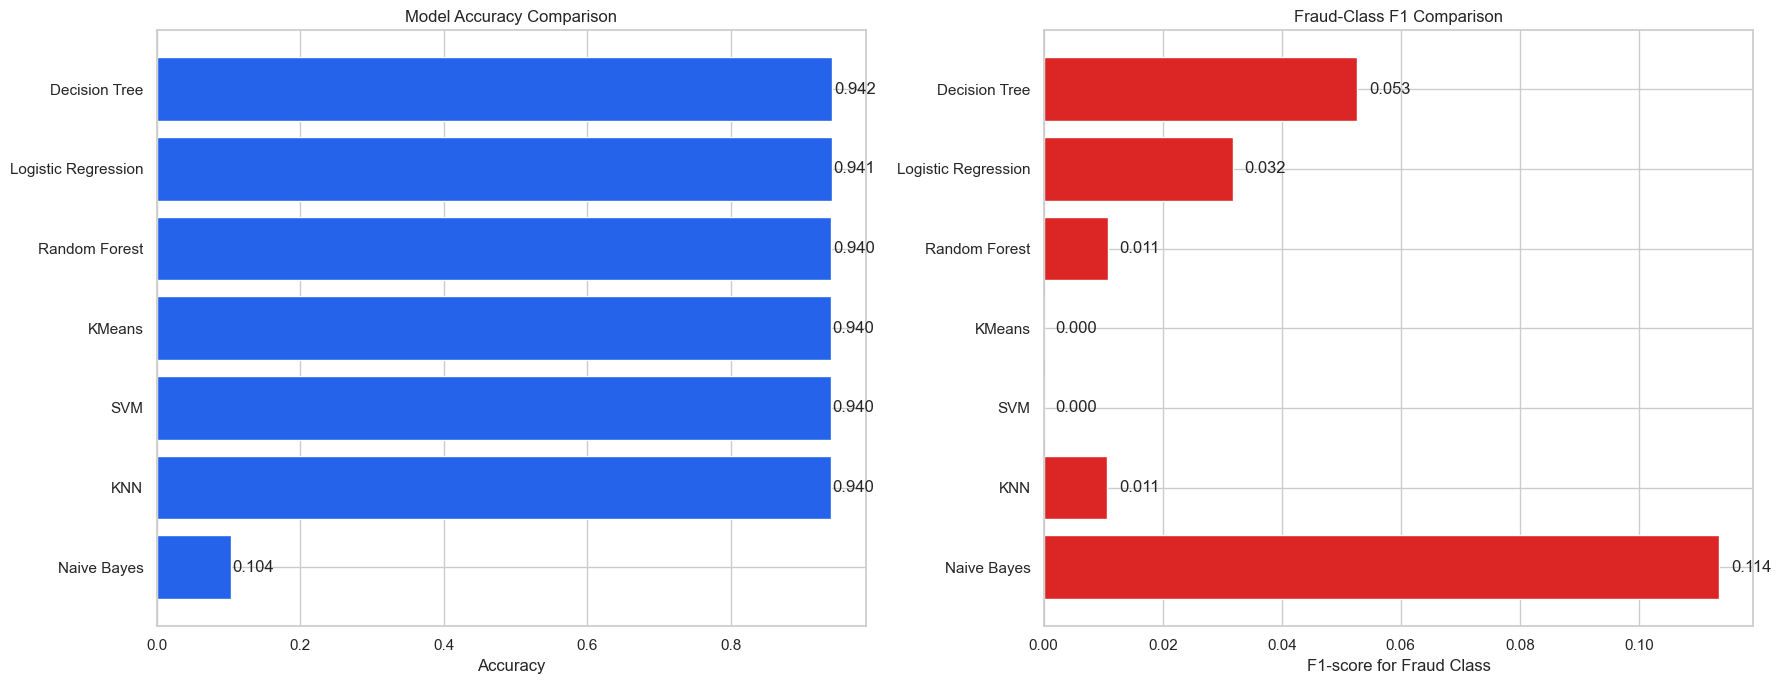

In [19]:
metric_plot_df = final_comparison_df.sort_values("accuracy", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(metric_plot_df["model"], metric_plot_df["accuracy"], color="#2563eb")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_xlabel("Accuracy")
for idx, value in enumerate(metric_plot_df["accuracy"]):
    axes[0].text(value + 0.002, idx, f"{value:.3f}", va="center")

axes[1].barh(metric_plot_df["model"], metric_plot_df["f1_fraud"], color="#dc2626")
axes[1].set_title("Fraud-Class F1 Comparison")
axes[1].set_xlabel("F1-score for Fraud Class")
for idx, value in enumerate(metric_plot_df["f1_fraud"]):
    axes[1].text(value + 0.002, idx, f"{value:.3f}", va="center")

plt.tight_layout()
plt.show()

## 20. Confusion Matrices for Every Model

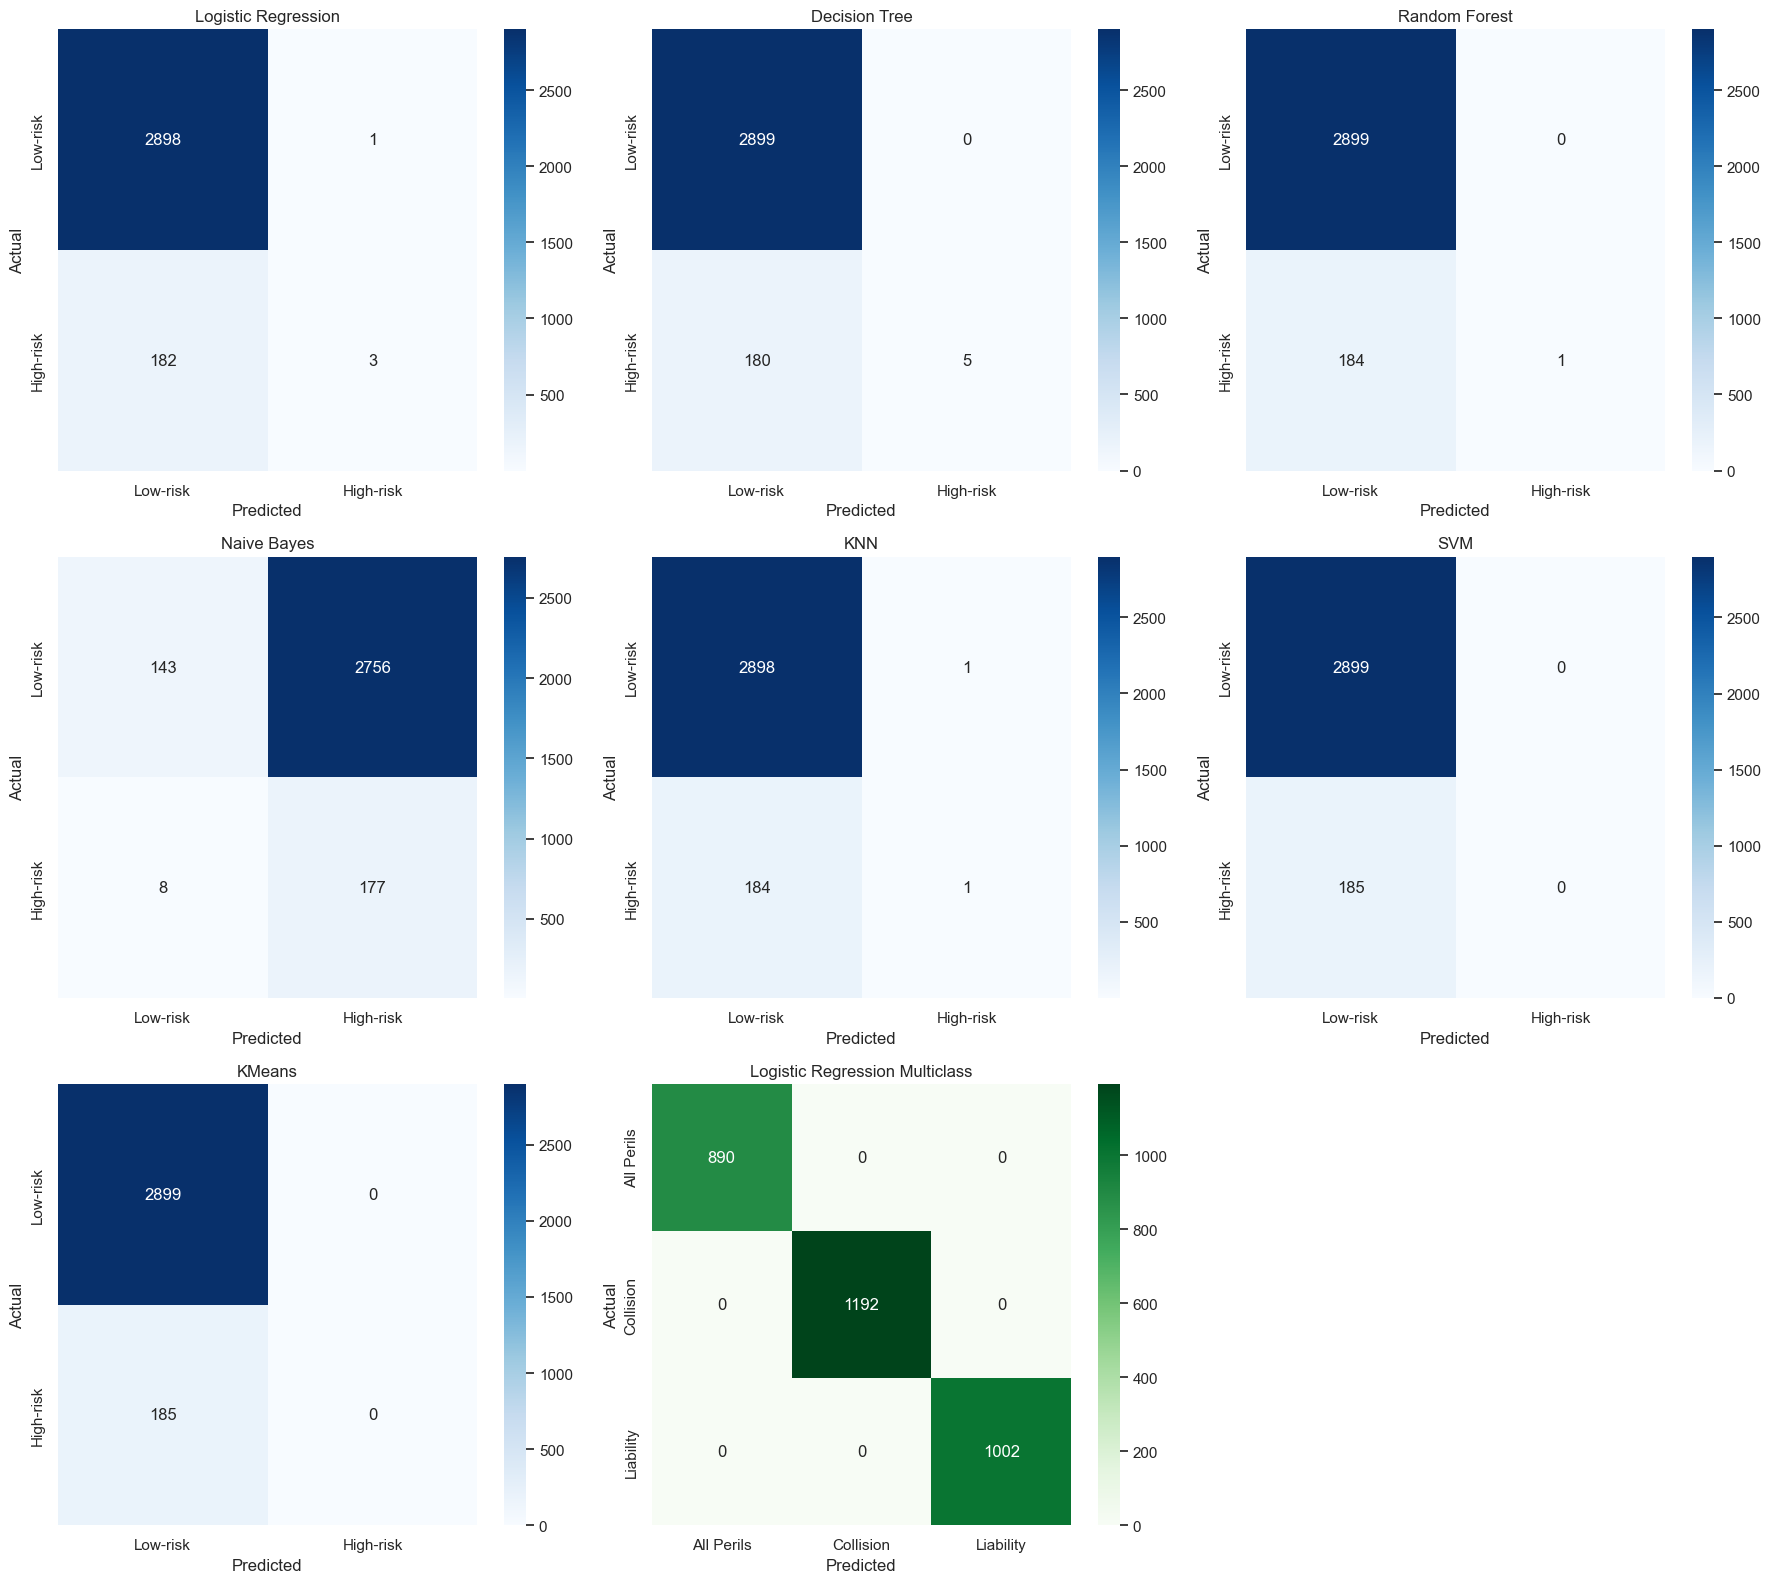

In [20]:
def get_model_predictions(model_name):
    rows = all_predictions_df[all_predictions_df["model"] == model_name]
    return rows["actual"].to_numpy(), rows["predicted"].to_numpy()

models_for_cm = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Naive Bayes",
    "KNN",
    "SVM",
    "KMeans",
]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, model_name in zip(axes, models_for_cm):
    actual, pred = get_model_predictions(model_name)
    cm = confusion_matrix(actual, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low-risk", "High-risk"],
        yticklabels=["Low-risk", "High-risk"],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Multiclass matrix in the final slot.
cm_mc = confusion_matrix(y_test_mc, best_mc_pred)
sns.heatmap(
    cm_mc,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=multiclass_encoder.classes_,
    yticklabels=multiclass_encoder.classes_,
    ax=axes[7],
)
axes[7].set_title("Logistic Regression Multiclass")
axes[7].set_xlabel("Predicted")
axes[7].set_ylabel("Actual")
axes[8].axis("off")

plt.tight_layout()
plt.show()

## 21. Save All Best Models with Pickle and Joblib

In [21]:
saved_model_records = []

for model_name, model_info in trained_models.items():
    bundle = {
        "project": "RiskProof AI",
        "module": "Claim fraud / risk scoring" if model_name != "Logistic Regression Multiclass" else "Policy type multiclass demo",
        "model_name": model_name,
        "model": model_info["model"],
        "parameters": model_info.get("parameters", {}),
        "feature_columns": model_info.get("feature_columns", X_encoded.columns.tolist()),
        "risk_label_map": risk_label_map,
        "target_column": target_col,
        "excluded_columns": drop_cols,
        "target_encoder": model_info.get("target_encoder"),
    }
    pkl_path, joblib_path = save_model_bundle(model_name, bundle)
    saved_model_records.append({
        "model": model_name,
        "pickle_path": str(pkl_path),
        "joblib_path": str(joblib_path),
    })

best_model_bundle = {
    "project": "RiskProof AI",
    "module": "Final best claim fraud / risk scoring model",
    "selection_rule": "Highest test accuracy among eligible binary models; ties resolved by fraud F1 and balanced accuracy.",
    "model_name": best_model_name,
    "best_accuracy": best_model_accuracy,
    "model": trained_models[best_model_name]["model"],
    "parameters": trained_models[best_model_name].get("parameters", {}),
    "feature_columns": X_encoded.columns.tolist(),
    "risk_label_map": risk_label_map,
    "target_column": target_col,
    "excluded_columns": drop_cols,
    "comparison_metrics": comparison_df.to_dict(orient="records"),
}

with open("riskproof_ai_best_model.pkl", "wb") as f:
    pickle.dump(best_model_bundle, f)
joblib.dump(best_model_bundle, "riskproof_ai_best_model.joblib")

saved_model_records.append({
    "model": "FINAL_BEST_MODEL",
    "pickle_path": "riskproof_ai_best_model.pkl",
    "joblib_path": "riskproof_ai_best_model.joblib",
})

saved_models_df = pd.DataFrame(saved_model_records)
saved_models_df.to_csv(OUTPUT_DIR / "saved_model_files.csv", index=False)
display(saved_models_df)

print("Final best model saved as:")
print("riskproof_ai_best_model.pkl")
print("riskproof_ai_best_model.joblib")

,model,pickle_path,joblib_path
0,Simple Linear Regression,saved_models\simple_linear_regression.pkl,saved_models\simple_linear_regression.joblib
1,Multiple Linear Regression,saved_models\multiple_linear_regression.pkl,saved_models\multiple_linear_regression.joblib
2,Logistic Regression,saved_models\logistic_regression.pkl,saved_models\logistic_regression.joblib
3,Decision Tree,saved_models\decision_tree.pkl,saved_models\decision_tree.joblib
4,Random Forest,saved_models\random_forest.pkl,saved_models\random_forest.joblib
5,Naive Bayes,saved_models\naive_bayes.pkl,saved_models\naive_bayes.joblib
6,KNN,saved_models\knn.pkl,saved_models\knn.joblib
7,SVM,saved_models\svm.pkl,saved_models\svm.joblib
8,KMeans,saved_models\kmeans.pkl,saved_models\kmeans.joblib
9,Logistic Regression Multiclass,saved_models\logistic_regression_multiclass.pkl,saved_models\logistic_regression_multiclass.jo...


Final best model saved as:
riskproof_ai_best_model.pkl
riskproof_ai_best_model.joblib


## 22. Demo Prediction Using the Final Best Model

In [22]:
with open("riskproof_ai_best_model.pkl", "rb") as f:
    loaded_best_bundle = pickle.load(f)

loaded_model = loaded_best_bundle["model"]
sample_input = X_test.iloc[[0]].copy()
sample_actual = int(y_test.iloc[0])
sample_prediction = int(loaded_model.predict(sample_input)[0])

print("Loaded model name:", loaded_best_bundle["model_name"])
print("Actual class:", sample_actual, "-", risk_label_map[sample_actual])
print("Predicted class:", sample_prediction, "-", risk_label_map[sample_prediction])

if hasattr(loaded_model, "predict_proba"):
    sample_score = float(loaded_model.predict_proba(sample_input)[0][1])
    print(f"Predicted high-risk probability: {sample_score:.4f}")
elif hasattr(loaded_model, "decision_function"):
    sample_score = float(loaded_model.decision_function(sample_input)[0])
    print(f"Predicted high-risk decision score: {sample_score:.4f}")

print("\nThis is the demo output you can show as RiskProof AI's structured claim-risk scoring module.")

Loaded model name: Decision Tree
Actual class: 0 - Low-risk / genuine claim
Predicted class: 0 - Low-risk / genuine claim
Predicted high-risk probability: 0.0045

This is the demo output you can show as RiskProof AI's structured claim-risk scoring module.
